## Project Title

## Flight Price Prediction using Machine Learning

## Problem Statement

Flight ticket prices change based on multiple factors such as airline, journey date, duration, number of stops, and departure time. 

It is difficult for users to estimate the correct ticket price manually. Traditional methods fail to capture complex relationships between these factors.

This project aims to build a machine learning model to predict flight ticket prices based on historical data.

## Objective

- Predict flight ticket prices accurately
- Identify important factors affecting price
- Help users estimate ticket cost before booking

## Problem Type

Regression Problem (Output is continuous value → Price)V


## Dataset Description

The dataset contains flight booking details with multiple features affecting ticket price.

Total Rows: 10683  
Total Columns: 11  

Features:

1. Airline – Name of airline
2. Date_of_Journey – Travel date
3. Source – Departure city
4. Destination – Arrival city
5. Route – Travel route
6. Dep_Time – Departure time
7. Arrival_Time – Arrival time
8. Duration – Total travel duration
9. Total_Stops – Number of stops
10. Additional_Info – Extra details
11. Price – Target variable (ticket price)

## importing Required Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and Initial Exploration


In this step, i load the dataset and perform an initial exploration to
understand its structure, size, and data types. This helps identify
potential data quality issues early in the analysis.

In [10]:
df=pd.read_excel(r"C:\Users\MY PC\AppData\Local\Temp\3a63df22-0ce8-42be-96bf-3ccda55cbe90_flight-fare.zip.e90\Flight_Fare.xlsx")

In [11]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


### Dataset Shape

i check the number of rows and columns in the dataset to understand
the overall size of the data.

In [12]:
df.shape

(10683, 11)

## Display first few rows

In [13]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


### Dataset Information

This step provides information about column names, data types,
and non-null counts, helping us verify data consistency

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [15]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


## Data Quality Checks

Before performing analysis and modeling, it is important to check the
dataset for missing values and duplicate records to ensure data reliability.

### Missing Values Check

This step checks whether any columns contain missing values that
could affect model performance.

In [16]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [17]:
df.dropna(inplace=True)

In [18]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

### Duplicate Records Check

Duplicate records can introduce bias into the model. This step
verifies whether any duplicate rows exist in the dataset.

In [19]:
df.duplicated().sum()

np.int64(220)

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df.duplicated().sum()

np.int64(0)

This step checks whether there are duplicate column names in the dataset.

Output shows all columns have count = 1, which means:
- No duplicate columns are present
- Dataset structure is clean and consistent

In [22]:
df.columns.value_counts()

Airline            1
Date_of_Journey    1
Source             1
Destination        1
Route              1
Dep_Time           1
Arrival_Time       1
Duration           1
Total_Stops        1
Additional_Info    1
Price              1
Name: count, dtype: int64

This step analyzes the distribution of airlines in the dataset.

It helps to:
- Understand which airline appears most frequently
- Identify imbalance in data
- Useful for feature importance analysis

In [23]:
df.Airline.value_counts()

Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1694
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

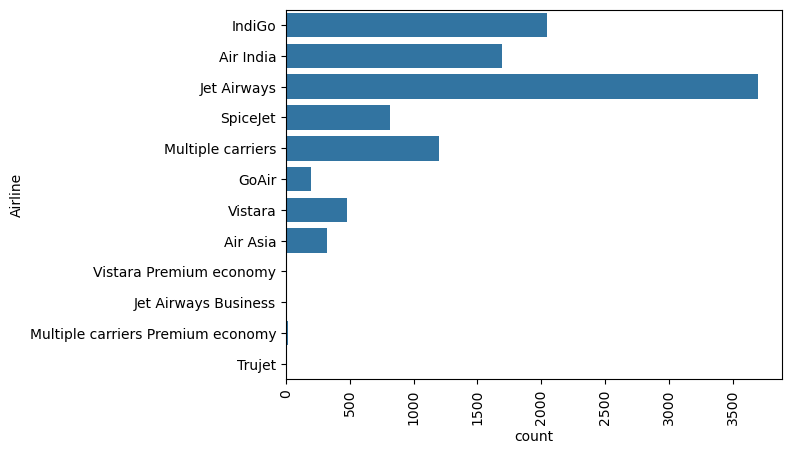

In [24]:
sns.countplot(df["Airline"])
plt.xticks(rotation=90)
plt.show()

## Source Analysis

This step analyzes the distribution of source cities in the dataset.

Observations:
- Delhi has the highest number of flights
- Followed by Kolkata and Bangalore
- Chennai has the least number of flights

This helps understand which locations have more flight traffic.

In [25]:
df.Source.value_counts()

Source
Delhi       4345
Kolkata     2860
Banglore    2179
Mumbai       697
Chennai      381
Name: count, dtype: int64

## Destination Analysis

This step shows the distribution of destination cities.

Observations:
- Cochin has the highest number of flights
- Bangalore and Delhi are also frequent destinations

This helps identify popular travel routes.

In [26]:
df.Destination.value_counts()

Destination
Cochin       4345
Banglore     2860
Delhi        1265
New Delhi     914
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

## Total Stops Analysis

This step analyzes the number of stops in flights.

Observations:
- Most flights have 1 stop
- Non-stop flights are also common
- Flights with more than 2 stops are very rare

This feature is important because more stops usually increase travel time and affect ticket price.

In [27]:
df.Total_Stops.value_counts()

Total_Stops
1 stop      5625
non-stop    3475
2 stops     1318
3 stops       43
4 stops        1
Name: count, dtype: int64

## Data Feature Engineering

The Date_of_Journey column is converted into two new features:
- Journey_day
- Journey_month

Reason:
Machine learning models cannot understand raw date format.
So we extract useful numerical information.

After extraction, the original column is removed.

In [28]:
df["Journey_day"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.day
df["Journey_month"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.month

In [29]:
df.drop("Date_of_Journey", axis=1,inplace=True)

## Departure Time Processing

Departure time is split into:
- Hour
- Minutes

Reason:
Time is important for pricing, but ML models need numerical values.

Original Dep_Time column is dropped after extraction.

In [30]:
df["Dep_hour"] = pd.to_datetime(df["Dep_Time"], format="%H:%M").dt.hour
df["Dep_min"] = pd.to_datetime(df["Dep_Time"], format="%H:%M").dt.minute

In [31]:
df.drop("Dep_Time", axis=1, inplace=True)

## Arrival Time Processing

Arrival time contains date + time, so first we extract only time.

Then we convert it into:
- Arrival_hour
- Arrival_min

This makes the feature usable for machine learning.

In [32]:
df["Arrival_Time"] = df["Arrival_Time"].apply(lambda x: x.split(" ")[0])

In [33]:
df["Arrival_hour"] = pd.to_datetime(df["Arrival_Time"], format="%H:%M").dt.hour
df["Arrival_min"] = pd.to_datetime(df["Arrival_Time"], format="%H:%M").dt.minute

In [34]:
df.drop("Arrival_Time", axis=1, inplace=True)

## Duration

Duration is given in format like "2h 50m".

Steps:
1. Remove 'h' and 'm'
2. Split into hours and minutes
3. Convert everything into total minutes

Example:
"2h 50m" → 170 minutes

Reason:
Machine learning models work better with numerical values.

In [35]:
df["Duration"] = df["Duration"].str.replace("h", " ").str.replace("m", "")
df["Duration"] = df["Duration"].str.split()

In [36]:
df["Duration"] = df["Duration"].apply(lambda x: int(x[0])*60 + (int(x[1]) if len(x)>1 else 0))

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10462 non-null  object
 1   Source           10462 non-null  object
 2   Destination      10462 non-null  object
 3   Route            10462 non-null  object
 4   Duration         10462 non-null  int64 
 5   Total_Stops      10462 non-null  object
 6   Additional_Info  10462 non-null  object
 7   Price            10462 non-null  int64 
 8   Journey_day      10462 non-null  int32 
 9   Journey_month    10462 non-null  int32 
 10  Dep_hour         10462 non-null  int32 
 11  Dep_min          10462 non-null  int32 
 12  Arrival_hour     10462 non-null  int32 
 13  Arrival_min      10462 non-null  int32 
dtypes: int32(6), int64(2), object(6)
memory usage: 980.8+ KB


In [38]:
df["Total_Stops"] = df["Total_Stops"].map({"non-stop":0,"1 stop": 1, "2 stop" :2, "3 stop" :3, "4 stop" : 4})

In [39]:
df.drop(["Route", "Additional_Info"], axis=1, inplace= True)

In [40]:
Airline = pd.get_dummies(df["Airline"],drop_first=True)

In [41]:
Source = pd.get_dummies(df["Source"],drop_first=True)

In [42]:
Destination = pd.get_dummies(df["Destination"],drop_first=True)

In [43]:
df.drop(["Airline","Source","Destination"], axis=1,inplace=True)

In [44]:
df=pd.concat([df, Airline, Source, Destination],axis=1)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Duration                           10462 non-null  int64  
 1   Total_Stops                        9100 non-null   float64
 2   Price                              10462 non-null  int64  
 3   Journey_day                        10462 non-null  int32  
 4   Journey_month                      10462 non-null  int32  
 5   Dep_hour                           10462 non-null  int32  
 6   Dep_min                            10462 non-null  int32  
 7   Arrival_hour                       10462 non-null  int32  
 8   Arrival_min                        10462 non-null  int32  
 9   Air India                          10462 non-null  bool   
 10  GoAir                              10462 non-null  bool   
 11  IndiGo                             10462 non-null  bool   


## Removing Duplicate Columns

his step removes duplicate columns from the dataset.

Sometimes during encoding or merging, duplicate columns may appear.
These can affect model performance and create confusion.

So we ensure all columns are unique.

In [46]:
df = df.loc[:, ~df.columns.duplicated()]

## Handling Missing Values

Missing values in Total_Stops are replaced with 0.

Reason:
Missing value may indicate no stops (non-stop flight).

Handling missing values is important because ML models cannot work with null values.

In [47]:
df["Total_Stops"]=df["Total_Stops"].fillna(0)

## Converting  Data Types

All features are converted into integer type.

Reason:
Machine learning models require numerical input.
After encoding and preprocessing, all features are numeric.

This step ensures consistency in the dataset.

In [48]:
df=df.astype(int)

## Final Dataset  Check

This step checks:
- Total number of rows and columns
- Data types
- Missing values

Observation:
All columns are numeric (int64) and no missing values exist.

This confirms the dataset is ready for model training.

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Duration                           10462 non-null  int64
 1   Total_Stops                        10462 non-null  int64
 2   Price                              10462 non-null  int64
 3   Journey_day                        10462 non-null  int64
 4   Journey_month                      10462 non-null  int64
 5   Dep_hour                           10462 non-null  int64
 6   Dep_min                            10462 non-null  int64
 7   Arrival_hour                       10462 non-null  int64
 8   Arrival_min                        10462 non-null  int64
 9   Air India                          10462 non-null  int64
 10  GoAir                              10462 non-null  int64
 11  IndiGo                             10462 non-null  int64
 12  Jet Airways            

## Outlier Detection

## Duration Boxplot

Boxplot is used to detect outliers in Duration.

Observations:
- Most flight durations are within a normal range
- Some flights have very high duration values (outliers)

These extreme values may affect model performance.

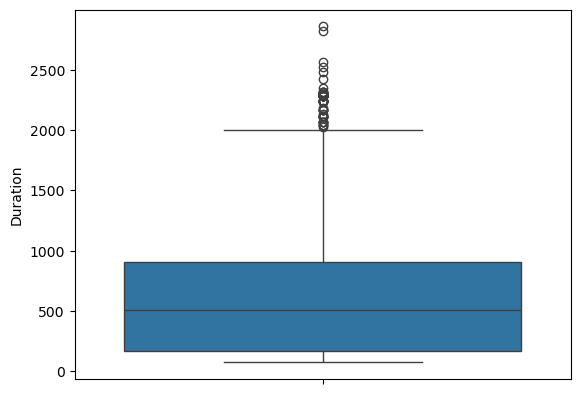

In [50]:
sns.boxplot(df["Duration"])
plt.show()

## Price Boxplot

Boxplot shows distribution of ticket prices.

Observations:
- Most prices are in a normal range
- Some very high prices are outliers

Outliers can impact prediction accuracy.

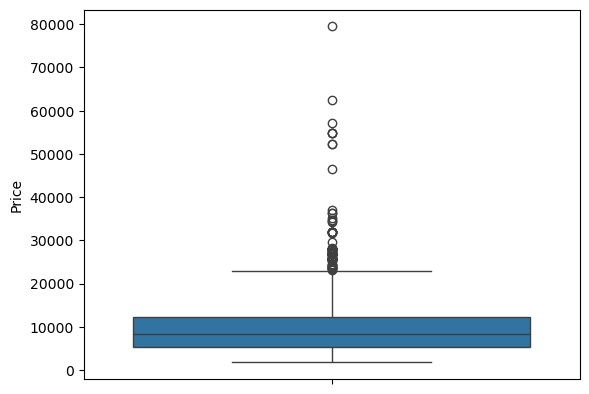

In [51]:
sns.boxplot(df["Price"])
plt.show()

## IQR Method 

IQR (Interquartile Range) is used to detect outliers.

Steps:
- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 - Q1

Outliers:
Values below (Q1 - 1.5 * IQR) or above (Q3 + 1.5 * IQR)

This helps identify extreme values in Price.

In [52]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)
IQR = Q3-Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


## Duration

In [53]:
Q1 = df["Duration"].quantile(0.25)
Q3 = df["Duration"].quantile(0.75)
IQR = Q3-Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


## Splitting Features and Target 

The dataset is divided into:

X → Input features (independent variables)
y → Target variable (Price)

Price is what we want to predict.

All other columns are used to train the model.

After preprocessing, the dataset is clean, structured, and fully numerical.

Key steps performed:
- Removed duplicate columns
- Handled missing values
- Converted all features to numeric format
- Detected outliers using boxplots and IQR method
- Split dataset into features (X) and target (y)

This prepared dataset is now ready for training machine learning models.

In [54]:
X= df.drop("Price",axis=1)

In [55]:
Y=df.Price

In [56]:
X

,Duration,Total_Stops,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Air India,GoAir,...,Trujet,Vistara,Vistara Premium economy,Chennai,Delhi,Kolkata,Mumbai,Cochin,Hyderabad,New Delhi
0,170,0,24,3,22,20,1,10,0,0,...,0,0,0,0,0,0,0,0,0,1
1,445,0,1,5,5,50,13,15,1,0,...,0,0,0,0,0,1,0,0,0,0
2,1140,0,9,6,9,25,4,25,0,0,...,0,0,0,0,1,0,0,1,0,0
3,325,1,12,5,18,5,23,30,0,0,...,0,0,0,0,0,1,0,0,0,0
4,285,1,1,3,16,50,21,35,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,150,0,9,4,19,55,22,25,0,0,...,0,0,0,0,0,1,0,0,0,0
10679,155,0,27,4,20,45,23,20,1,0,...,0,0,0,0,0,1,0,0,0,0
10680,180,0,27,4,8,20,11,20,0,0,...,0,0,0,0,0,0,0,0,0,0
10681,160,0,1,3,11,30,14,10,0,0,...,0,1,0,0,0,0,0,0,0,1


In [57]:

Y

0         3897
1         7662
2        13882
3         6218
4        13302
         ...  
10678     4107
10679     4145
10680     7229
10681    12648
10682    11753
Name: Price, Length: 10462, dtype: int64

## Train-Test Split

In [58]:
from sklearn.model_selection import train_test_split 

The dataset is divided into training and testing sets.

- 80% data → Training (to train model)
- 20% data → Testing (to evaluate model)

random_state=42 ensures reproducibility (same split every time).

In [59]:
X_train,X_test,Y_train,Y_test = train_test_split (X,Y, test_size = 0.2,random_state = 42)

## Random Forest Regressor

Random Forest is an ensemble learning method.

It builds multiple decision trees and combines their predictions.

Parameters:
- n_estimators=200 → number of trees
- max_depth=20 → limits tree depth (controls overfitting)

This model captures complex patterns in data.

In [60]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42
)



In [61]:
model.fit(X_train,Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [62]:
Y_pred = model.predict(X_test)

In [63]:
Y_pred

array([14610.15158333,  3846.6177467 ,  4258.68234343, ...,
       10891.38003125,  7502.61685714, 12666.36      ], shape=(2093,))

## Model Evaluation

R2 Score:
- Measures how well the model explains variance
- Value closer to 1 = better

Here: 0.81 → Good performance

MAE (Mean Absolute Error):
- Average prediction error
- Lower is better

Here: ~1159 → model prediction error is around ₹1159

In [64]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(Y_test, Y_pred))
print("MAE:", mean_absolute_error(Y_test, Y_pred))

R2 Score: 0.818700948789586
MAE: 1159.3893818788558


## Decision Tree

Decision Tree uses a tree structure to make predictions.

Observation:
- Lower R2 compared to Random Forest
- Higher error

Reason:
Single tree → overfitting / less generalization

In [65]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit (X_train, Y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [66]:
Y_pred = model.predict(X_test)


In [67]:
Y_pred

array([13502.,  3841.,  4148., ..., 10262.,  6795., 13377.], shape=(2093,))

In [68]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(Y_test, Y_pred))
print("MAE:", mean_absolute_error(Y_test, Y_pred))

R2 Score: 0.719607802706649
MAE: 1378.3410176779742


## XGBoost

XGBoost is an advanced boosting algorithm.

It builds models sequentially and improves errors step-by-step.

Observation:
- Similar performance to Random Forest
- Slightly higher MAE

Very powerful for structured/tabular data.

In [69]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [70]:
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42)

In [71]:
model.fit(X_train,Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [72]:

Y_pred = model.predict(X_test)

In [73]:
Y_pred

array([15137.124 ,  3831.4236,  4205.605 , ..., 10950.778 , 10451.716 ,
       10921.603 ], shape=(2093,), dtype=float32)

In [74]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(Y_test, Y_pred))
print("MAE:", mean_absolute_error(Y_test, Y_pred))

R2 Score: 0.811070442199707
MAE: 1330.5374755859375


## Gradient Boosting

Gradient Boosting improves predictions by reducing errors step-by-step.

Works similar to XGBoost but slightly slower.

Performance is good but not better than Random Forest here.

In [75]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(n_estimators=200,
                                 learning_rate=0.05,
                                 max_depth=5,
                                 random_state=42)
model.fit(X_train, Y_train)


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [76]:

Y_pred = model.predict(X_test)

In [77]:
Y_pred

array([14724.86427516,  3956.92132159,  4264.31226504, ...,
       10762.28978492, 10316.05702557, 11239.65820228], shape=(2093,))

In [78]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(Y_test, Y_pred))
print("MAE:", mean_absolute_error(Y_test, Y_pred))

R2 Score: 0.8186894272578304
MAE: 1300.9053475692137


 ## ExtraTreesRegressor

Extra Trees is similar to Random Forest but uses more randomness.

Observation:
- Slightly lower accuracy than Random Forest
- Faster training

In [79]:
from sklearn.ensemble import ExtraTreesRegressor

In [80]:
model = ExtraTreesRegressor()
model.fit(X_train,Y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the 

In [81]:
Y_pred = model.predict(X_test)

In [82]:
from sklearn.metrics import r2_score,mean_absolute_error
print("R2 score:", r2_score(Y_test,Y_pred))
print("MAE:", mean_absolute_error(Y_test, Y_pred))

R2 score: 0.7776415204834254
MAE: 1237.5688891543239


## FINAL CONCLUSION

Multiple regression models were trained and evaluated.

Among all models, Random Forest Regressor performed best with:
- Highest R2 Score (~0.81)
- Lowest MAE (~1159)

This indicates that Random Forest captures complex relationships effectively and provides more accurate predictions.

Therefore, Random Forest is selected as the final model for flight price prediction.

In [83]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": Y_test,
    "Predicted": Y_pred
})

comparison.head()

,Actual,Predicted
2150,17996,14662.205
3784,3873,3841.000
714,4462,4251.510
7558,2228,4910.285
7413,4991,4885.000


In [85]:
import pickle
pickle.dump(model,
            open("flight_model.pkl", "wb"))

In [86]:
import os

In [87]:
print(os.getcwd())

C:\Users\MY PC\Desktop
